# Notebook 03 — Radiative Transfer Forward Model

## Overview
This notebook builds and explores the **satellite radiative transfer forward model** — the mathematical bridge between atmospheric CO₂ concentration and the radiance spectrum measured by the satellite.

## The Forward Model

$$I(\nu) = I_{\odot}(\nu) \cdot A_s \cdot \cos\theta_s \cdot \exp\left(-M \cdot \sigma(\nu) \cdot N_{\text{col}}\right)$$

| Term | Meaning |
|------|---------|
| $I_{\odot}(\nu)$ | Normalised solar irradiance (Planck blackbody) |
| $A_s$ | Surface albedo (Lambertian) |
| $\cos\theta_s$ | Solar zenith angle weighting |
| $M = 1/\mu_s + 1/\mu_v$ | Two-way geometric air-mass factor |
| $N_{\text{col}}$ | CO₂ vertical column amount [molecules/cm²] |

In [2]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt

In [3]:

from spectroscopy import absorption_cross_section, doppler_hwhm, lorentz_hwhm
from radiative_transfer import (
    solar_irradiance,
    air_mass_factor,
    column_amount,
    forward_model,
    standard_atmosphere_profile,
    plot_forward_model,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Solar Irradiance Spectrum

We model the Sun as a blackbody with $T_{\odot} \approx 5778$ K.

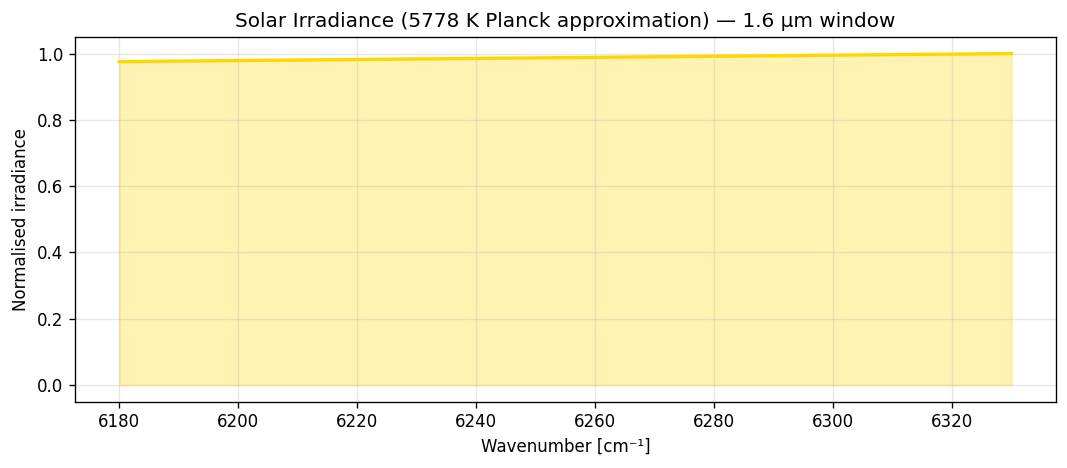

In [4]:
# CO₂ 1.6 µm band: 6180–6330 cm⁻¹
nu = np.linspace(6180, 6330, 4000)

I_sun = solar_irradiance(nu)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(nu, I_sun, color='gold', lw=2)
ax.fill_between(nu, I_sun, alpha=0.3, color='gold')
ax.set_xlabel('Wavenumber [cm⁻¹]'); ax.set_ylabel('Normalised irradiance')
ax.set_title('Solar Irradiance (5778 K Planck approximation) — 1.6 µm window')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/03a_solar_irradiance.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Air-Mass Factor Geometry

The two-way air-mass factor $M = 1/\cos\theta_s + 1/\cos\theta_v$ determines how much atmosphere the photon traverses.

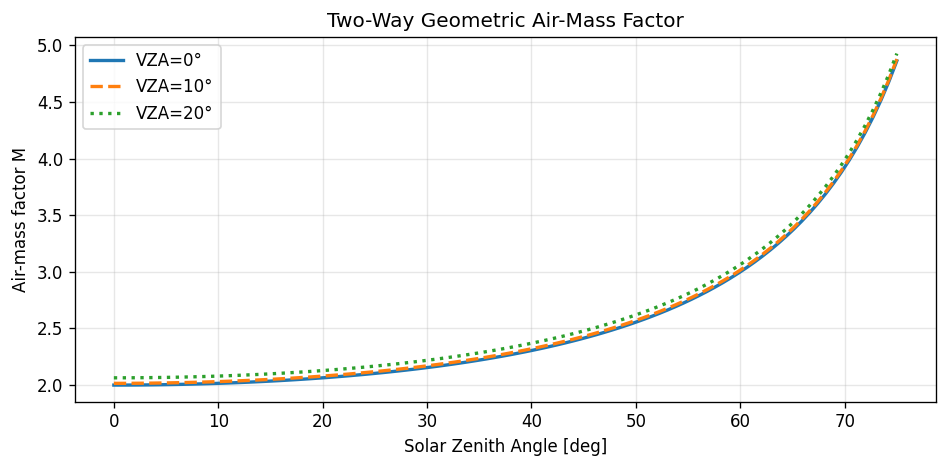

SZA=30°, nadir:  M = 2.155
SZA=60°, nadir:  M = 3.000


In [5]:
sza_range = np.linspace(0, 75, 100)

fig, ax = plt.subplots(figsize=(8, 4))
for vza, ls in zip([0, 10, 20], ['-', '--', ':']):
    amf = [air_mass_factor(s, vza) for s in sza_range]
    ax.plot(sza_range, amf, lw=2, ls=ls, label=f'VZA={vza}°')

ax.set_xlabel('Solar Zenith Angle [deg]')
ax.set_ylabel('Air-mass factor M')
ax.set_title('Two-Way Geometric Air-Mass Factor')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/03b_air_mass_factor.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'SZA=30°, nadir:  M = {air_mass_factor(30, 0):.3f}')
print(f'SZA=60°, nadir:  M = {air_mass_factor(60, 0):.3f}')

## 3. Standard Atmosphere Profile

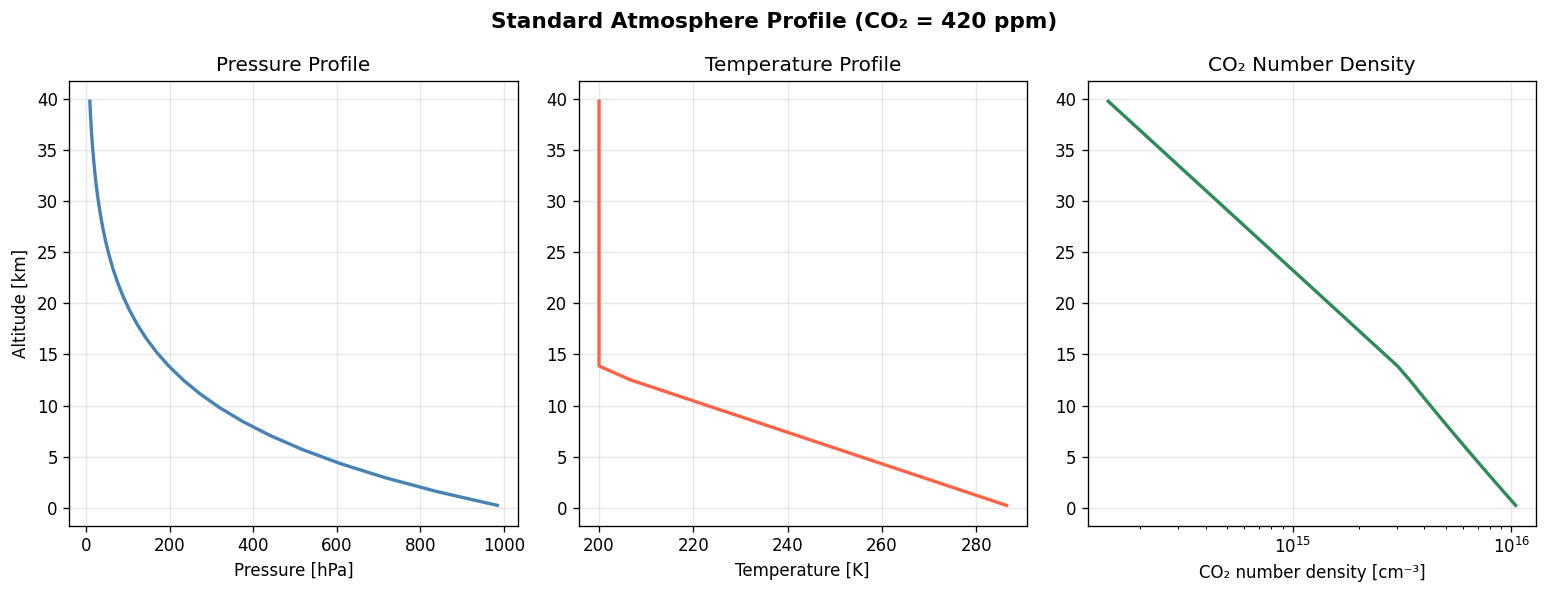

CO₂ column amount: 1.103e+22 molecules/cm²


In [6]:
profile = standard_atmosphere_profile(n_layers=30, co2_vmr_ppm=420.0)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

axes[0].plot(profile['pressure_Pa']/100, profile['altitude_km'], color='steelblue', lw=2)
axes[0].set_xlabel('Pressure [hPa]'); axes[0].set_ylabel('Altitude [km]')
axes[0].set_title('Pressure Profile')

axes[1].plot(profile['temperature_K'], profile['altitude_km'], color='tomato', lw=2)
axes[1].set_xlabel('Temperature [K]')
axes[1].set_title('Temperature Profile')

axes[2].plot(profile['number_density'], profile['altitude_km'], color='seagreen', lw=2)
axes[2].set_xlabel('CO₂ number density [cm⁻³]')
axes[2].set_title('CO₂ Number Density')
axes[2].set_xscale('log')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('Standard Atmosphere Profile (CO₂ = 420 ppm)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/03c_atmosphere_profile.png', dpi=150, bbox_inches='tight')
plt.show()

N_col = column_amount(profile['number_density'], profile['layer_thickness_cm'])
print(f'CO₂ column amount: {N_col:.3e} molecules/cm²')

## 4. Full Forward Model Simulation

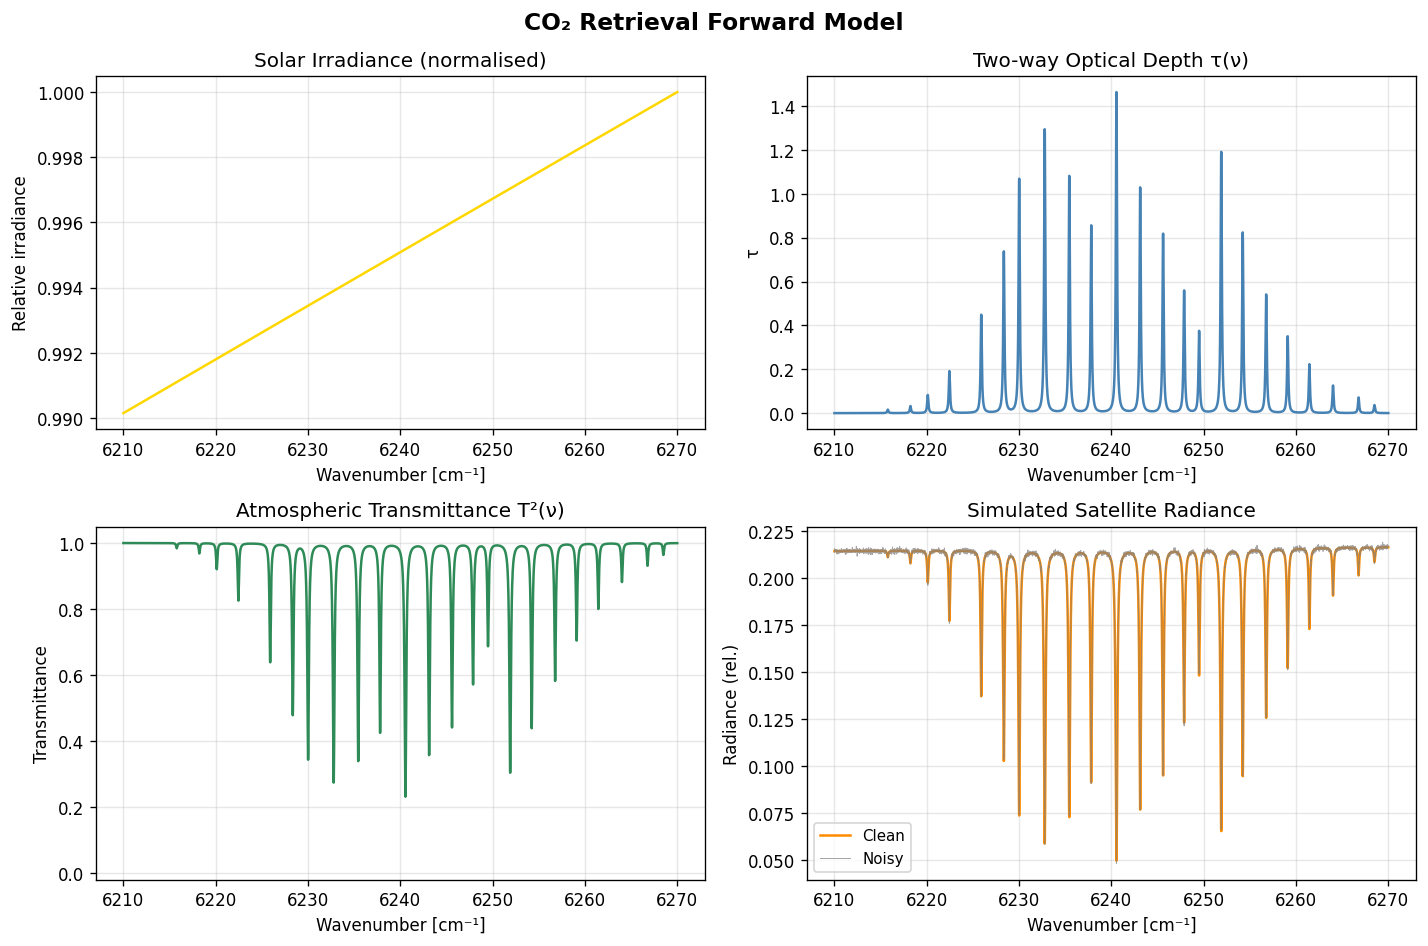

In [7]:
from hitran_model import hitran_cross_section, SYNTHETIC_CO2_LINES

nu = np.linspace(6210, 6270, 4000)
xsec = hitran_cross_section(nu, SYNTHETIC_CO2_LINES, 101325.0, 288.0)

amf = air_mass_factor(30.0, 0.0)   # SZA=30°, nadir view

result = forward_model(
    nu, xsec, N_col,
    air_mass=amf,
    surface_albedo=0.25,
    solar_zenith_deg=30.0,
    add_noise=True,
    snr=300.0,
)

plot_forward_model(result, savefig='../figures/03d_forward_model.png')

## 5. Surface Albedo Sensitivity

Surface reflectance strongly modulates the signal-to-noise of CO₂ measurements.  Ocean surfaces (~0.05) give much weaker signals than bright deserts (~0.35).

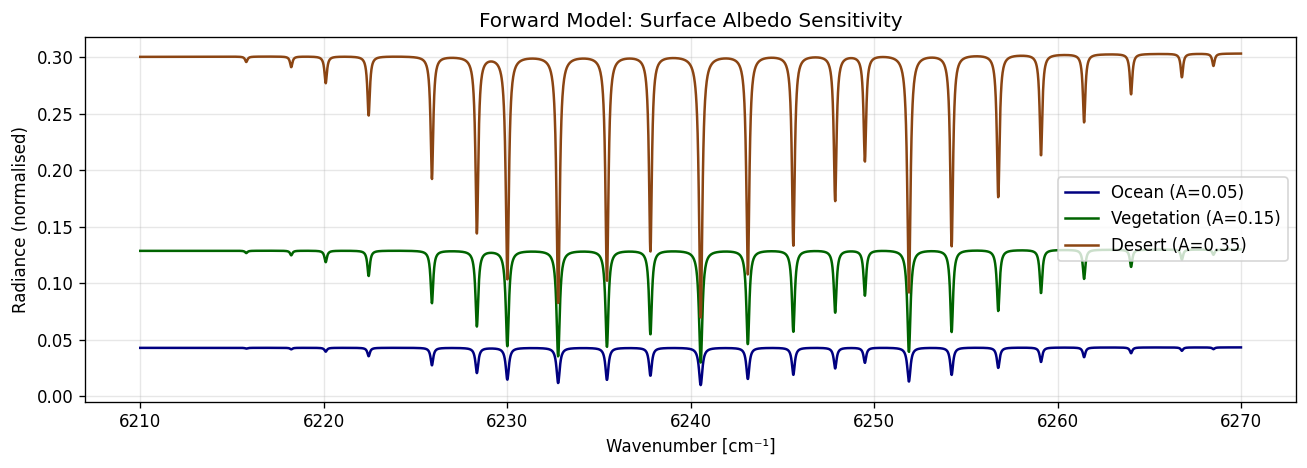

In [8]:
albedos = {'Ocean': 0.05, 'Vegetation': 0.15, 'Desert': 0.35}
colors  = ['navy', 'darkgreen', 'saddlebrown']

fig, ax = plt.subplots(figsize=(11, 4))
for (label, A), col in zip(albedos.items(), colors):
    res = forward_model(nu, xsec, N_col, air_mass=amf, surface_albedo=A,
                        solar_zenith_deg=30.0)
    ax.plot(nu, res['radiance'], lw=1.5, color=col, label=f'{label} (A={A})')

ax.set_xlabel('Wavenumber [cm⁻¹]'); ax.set_ylabel('Radiance (normalised)')
ax.set_title('Forward Model: Surface Albedo Sensitivity')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/03e_albedo_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()